# French Lyrics EDA + NLP Cleaning

This notebook analyzes:
- **Final merged dataset**: `mb_likely_french_stage2_enriched_genius_merged.csv`
- **French music overall dataset version** (for broad conclusions), generated in this notebook.

Outputs:
- NLP-ready clean CSV
- Overall French music CSV
- Figures saved to `/Users/danvoloshin/Desktop/masters/figures`

## 1) Setup

In [21]:
from __future__ import annotations
import json
import re
from collections import Counter, defaultdict
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

In [22]:
ROOT = Path('/Users/danvoloshin/Desktop/masters')
INPUT_CSV = ROOT / 'thesis_french_song_nlp/data/processed/musicbrainz/mb_likely_french_stage2_enriched_genius_merged.csv'
OUT_DIR = ROOT / 'thesis_french_song_nlp/data/processed/musicbrainz'
FIG_DIR = ROOT / 'figures'

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

NLP_CLEAN_CSV = OUT_DIR / 'mb_likely_french_stage2_nlp_clean.csv'
OVERALL_CSV = OUT_DIR / 'mb_likely_french_stage2_overall_french_music.csv'
SUMMARY_JSON = OUT_DIR / 'eda_summary.json'

print('Input:', INPUT_CSV)
print('Output dir:', OUT_DIR)
print('Figures dir:', FIG_DIR)

Input: /Users/danvoloshin/Desktop/masters/thesis_french_song_nlp/data/processed/musicbrainz/mb_likely_french_stage2_enriched_genius_merged.csv
Output dir: /Users/danvoloshin/Desktop/masters/thesis_french_song_nlp/data/processed/musicbrainz
Figures dir: /Users/danvoloshin/Desktop/masters/figures


## 2) Load Data and Schema Checks

In [23]:
df = pd.read_csv(INPUT_CSV, low_memory=False)

if 'decade' not in df.columns:
    df['year_num'] = pd.to_numeric(df['year'], errors='coerce')
    df['decade'] = ((df['year_num'] // 10) * 10).astype('Int64').astype(str) + 's'
    df.loc[df['year_num'].isna(), 'decade'] = 'Unknown'
else:
    df['year_num'] = pd.to_numeric(df['year'], errors='coerce')

lyrics_a = df['lyrics_text'] if 'lyrics_text' in df.columns else pd.Series('', index=df.index)
lyrics_b = df['lyrics_text.1'] if 'lyrics_text.1' in df.columns else pd.Series('', index=df.index)
df['lyrics_raw'] = lyrics_a.fillna(lyrics_b).fillna('').astype(str)

df['has_lyrics'] = df['lyrics_raw'].str.strip().ne('')

print('Shape:', df.shape)
print('Columns:', len(df.columns))
df.head(3)

Shape: (320355, 28)
Columns: 28


,year,song_title,artist_credit_name,artist_name,language_name,iso_code_3t,release_country_code,artist_country_code,track_id,recording_id,release_id,artist_id,likely_french_score,genre_name,genius_found,genius_song_id,genius_title,genius_artist,genius_url,genius_match_score,lyrics_found,lyrics_text,lyrics_source,lyrics_text.1,year_num,decade,lyrics_raw,has_lyrics
0,2007.0,Rue Lepic,Yves Montand,Yves Montand,French,fra,XE,FR,18502360.0,1939,1593001.0,345.0,5.0,NaN,True,1457202.0,Rue Lepic,Yves Montand,https://genius.com/Yves-montand-rue-lepic-lyrics,1.0,True,1 Contributor\nRue Lepic Lyrics\nRue Lepic\nDa...,genius,NaN,2007.0,2000s,1 Contributor\nRue Lepic Lyrics\nRue Lepic\nDa...,True
1,2004.0,Les Routiers,Yves Montand,Yves Montand,French,fra,FR,FR,24517993.0,1944,2093826.0,345.0,8.0,NaN,True,1608153.0,Les routiers,Yves Montand,https://genius.com/Yves-montand-les-routiers-l...,1.0,True,1 Contributor\nLes routiers Lyrics\nLa route e...,genius,NaN,2004.0,2000s,1 Contributor\nLes routiers Lyrics\nLa route e...,True
2,1998.0,Double peine,Zebda,Zebda,French,fra,FR,FR,12514833.0,10822,816938.0,1999.0,7.0,NaN,True,2281345.0,Double peine,Zebda,https://genius.com/Zebda-double-peine-lyrics,1.0,True,3 Contributors\nDouble peine Lyrics\nEn droit ...,genius,NaN,1998.0,1990s,3 Contributors\nDouble peine Lyrics\nEn droit ...,True


## 3) Helper Functions (Cleaning, Tokenization, Language Verification)

In [27]:
WORD_RE = re.compile(r"[a-zA-ZÀ-ÖØ-öø-ÿ']+")

# Non-French indicators frequently seen in scraped lyric noise
NON_FRENCH_HINTS = {
    "por", "pero", "los", "las", "esta", "está", "siempre", "y", "con", "del", "una",
    "the", "and", "you", "yeah", "baby"
}

def tokenize(text: str) -> list[str]:
    return WORD_RE.findall(str(text).lower())


def clean_lyrics(text: str) -> str:
    s = str(text)
    # Remove common scraping artifacts from Genius-like pages
    s = re.sub(r"^\s*\d+\s+Contributors?\s*", "", s, flags=re.IGNORECASE)
    s = re.sub(r"\bLyrics\b", "", s, flags=re.IGNORECASE)
    s = re.sub(r"\bEmbed\b", "", s, flags=re.IGNORECASE)
    s = re.sub(r"\[.*?\]", " ", s)  # [Chorus], [Verse], etc.
    s = re.sub(r"\s+", " ", s).strip()
    return s


def is_french_lyrics_signal(text: str) -> bool:
    t = clean_lyrics(text)
    words = tokenize(t)
    if len(words) < 12:
        return False

    markers = re.findall(
        r"\b(je|tu|il|elle|nous|vous|ils|elles|le|la|les|de|des|et|dans|que|qui|pour|pas|sur|avec|mais|une|un|est|ne|se|ce|ça|comme)\b",
        t.lower(),
    )
    french_ratio = len(markers) / max(len(words), 1)

    non_french_hits = sum(1 for w in words if w in NON_FRENCH_HINTS)
    non_french_ratio = non_french_hits / max(len(words), 1)

    # Stronger French gate to reduce mixed-language leakage
    return french_ratio >= 0.06 and non_french_ratio <= 0.20



## 4) Dataset Overview
- Dataset shape
- Missing values
- Songs with vs without lyrics
- Distribution of songs by years

In [28]:
dataset_shape = df.shape

# Missing values
missing_values = df.isna().sum().sort_values(ascending=False)
missing_report = missing_values.to_frame('missing_count')
missing_report['missing_pct'] = (missing_report['missing_count'] / len(df)) * 100

# Lyrics availability
songs_with_lyrics = int(df['has_lyrics'].sum())
songs_without_lyrics = int((~df['has_lyrics']).sum())
lyrics_pct = songs_with_lyrics / max(len(df), 1) * 100

print('Dataset shape:', dataset_shape)
print('Songs with lyrics:', songs_with_lyrics)
print('Songs without lyrics:', songs_without_lyrics)
print(f'Lyrics availability: {lyrics_pct:.2f}%')

missing_report.head(20)

Dataset shape: (320355, 28)
Songs with lyrics: 70922
Songs without lyrics: 249433
Lyrics availability: 22.14%


,missing_count,missing_pct
genre_name,320355,100.000000
lyrics_text.1,320259,99.970033
lyrics_text,249529,77.891402
lyrics_source,249433,77.861435
genius_url,111449,34.789218
genius_artist,111449,34.789218
genius_title,111449,34.789218
genius_song_id,111449,34.789218
artist_country_code,32281,10.076634
language_name,11178,3.489254


Distribution of songs by years within the dataset

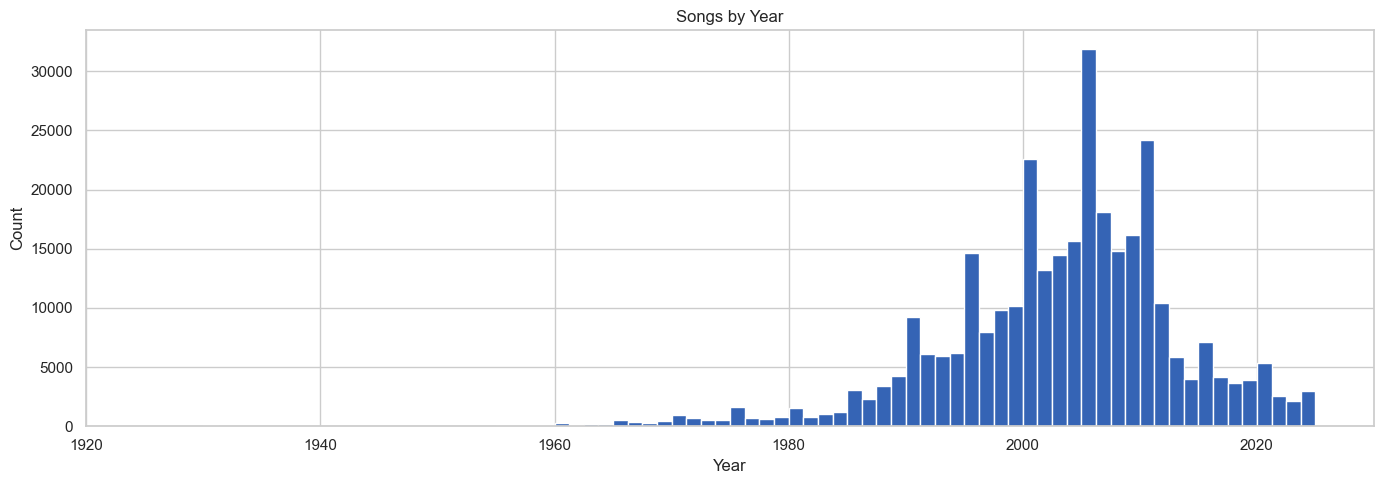

In [29]:
valid_years = df['year_num'].dropna().astype(int)
possible_years = valid_years[(valid_years >= 1850) & (valid_years <= 2026)]

plt.figure(figsize=(14, 5))
plt.hist(possible_years, bins=80, color='#3564b5', edgecolor='white')
plt.title('Songs by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(FIG_DIR / 'hist_songs_by_year.png', dpi=160)
plt.show()

## 5) Lyrics Quality Filtering (BERTopic-friendly)
This step removes low-value textual noise:
- instrumental / no-lyrics placeholders
- excessive chorus/refrain repeats
- scrape garbage (high non-letter ratio)
- extremely short lyrics (`< 20` words)

In [30]:
df['lyrics_clean'] = df['lyrics_raw'].map(clean_lyrics)
df['lyrics_word_count'] = df['lyrics_clean'].str.count(r"[A-Za-zÀ-ÖØ-öø-ÿ']+")

instrumental = df['lyrics_clean'].str.contains(
    r"\b(instrumental|sans paroles|no lyrics|music only)\b",
    case=False,
    regex=True,
)
chorus_repeat = df['lyrics_clean'].str.count(r"(?i)\b(chorus|refrain)\b") >= 3
non_letter_len = df['lyrics_clean'].str.replace(r"[A-Za-zÀ-ÖØ-öø-ÿ'\s]", "", regex=True).str.len()
garbage_ratio = non_letter_len / df['lyrics_clean'].str.len().clip(lower=1)
garbage = garbage_ratio > 0.35
too_short = df['lyrics_word_count'] < 20

df['quality_pass'] = ~(instrumental | chorus_repeat | garbage | too_short)

quality_filtered_out_count = int((df['has_lyrics'] & ~df['quality_pass']).sum())
extremely_short_lyrics_count = int((df['has_lyrics'] & too_short).sum())

print('Quality-filtered out (from songs with lyrics):', quality_filtered_out_count)
print('Extremely short lyrics (<20 words):', extremely_short_lyrics_count)

/var/folders/42/5ltlp1d15cjbgq4xcjxdbkym0000gn/T/ipykernel_15188/3110837496.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  instrumental = df['lyrics_clean'].str.contains(


Quality-filtered out (from songs with lyrics): 3628
Extremely short lyrics (<20 words): 740


## 6) Language Filtering
- Verify songs are French
- Remove songs without French lyrics for NLP clean output

In [31]:
lang = df['language_name'].fillna('').astype(str).str.lower() if 'language_name' in df.columns else pd.Series('', index=df.index)
iso = df['iso_code_3t'].fillna('').astype(str).str.lower() if 'iso_code_3t' in df.columns else pd.Series('', index=df.index)
french_meta = lang.str.contains('french', regex=False) | iso.isin(['fra', 'fre'])
french_signal = df['lyrics_clean'].map(is_french_lyrics_signal)

df['is_french_verified'] = french_meta & ((~df['has_lyrics']) | french_signal)

print('French-verified rows:', int(df['is_french_verified'].sum()))

French-verified rows: 215704


## 7) Decade-Based Analysis
- Number of songs per decade
- Number of artists per decade
- Number of genres per decade
- Number of unique words per decade (from clean lyrics)

In [32]:
# Overall French music scope (for broad conclusions)
overall_df = df[df['is_french_verified']].copy()
overall_df = overall_df.sort_values(['quality_pass', 'lyrics_word_count'], ascending=[False, False])
overall_df = overall_df.drop_duplicates(subset=['song_title', 'artist_name', 'year'], keep='first')

# NLP-ready scope: French + has lyrics + quality pass
nlp_df = df[df['is_french_verified'] & df['has_lyrics'] & df['quality_pass']].copy()

songs_per_decade = overall_df['decade'].value_counts(dropna=False).rename_axis('decade').reset_index(name='songs_count')
artists_per_decade = (
    overall_df.groupby('decade')['artist_name'].nunique().reset_index(name='artists_count')
)
genres_per_decade = (
    overall_df.groupby('decade')['genre_name'].nunique().reset_index(name='genres_count')
)

# Unique vocabulary per decade from NLP-clean lyrics
# Uses cleaned token pipeline if available; otherwise falls back to basic tokenizer.
unique_words_per_decade_rows = []
for dec, grp in nlp_df.groupby('decade'):
    dec_tokens = []
    for txt in grp['lyrics_clean'].astype(str):
        if 'extract_clean_tokens' in globals():
            dec_tokens.extend(extract_clean_tokens(txt))
        else:
            dec_tokens.extend(tokenize(txt))
    unique_words_per_decade_rows.append({'decade': dec, 'unique_words_count': len(set(dec_tokens))})

unique_words_per_decade = pd.DataFrame(unique_words_per_decade_rows)

songs_per_decade = songs_per_decade.sort_values('decade')
artists_per_decade = artists_per_decade.sort_values('decade')
genres_per_decade = genres_per_decade.sort_values('decade')
unique_words_per_decade = unique_words_per_decade.sort_values('decade')

songs_per_decade.head(), artists_per_decade.head(), genres_per_decade.head(), unique_words_per_decade.head()


(   decade  songs_count
 9   1920s           56
 8   1930s          105
 11  1940s           15
 7   1950s          492
 6   1960s         2057,
   decade  artists_count
 0  1920s             21
 1  1930s             28
 2  1940s              7
 3  1950s             86
 4  1960s            259,
   decade  genres_count
 0  1920s             0
 1  1930s             0
 2  1940s             0
 3  1950s             0
 4  1960s             0,
   decade  unique_words_count
 0  1920s                 181
 1  1930s                 582
 2  1940s                 175
 3  1950s                5608
 4  1960s               15935)

## 8) Lyrics Availability and Length
- % songs containing lyrics
- Lyrics length distribution
- Average lyrics length by decade

In [33]:
lyrics_availability_pct = overall_df['has_lyrics'].mean() * 100
print(f'Lyrics availability (French-verified overall dataset): {lyrics_availability_pct:.2f}%')

avg_lyric_len_by_decade = (
    nlp_df.groupby('decade')['lyrics_word_count']
    .mean()
    .reset_index(name='avg_lyrics_word_count')
    .sort_values('decade')
)
avg_lyric_len_by_decade.head(20)

Lyrics availability (French-verified overall dataset): 23.84%


,decade,avg_lyrics_word_count
0,1920s,348.000000
1,1930s,229.800000
2,1940s,198.500000
3,1950s,259.674419
4,1960s,248.889558
5,1970s,374.158068
6,1980s,358.304623
7,1990s,423.629911
8,2000s,384.969548
9,2010s,425.536496


Boxplot lyric length by decade

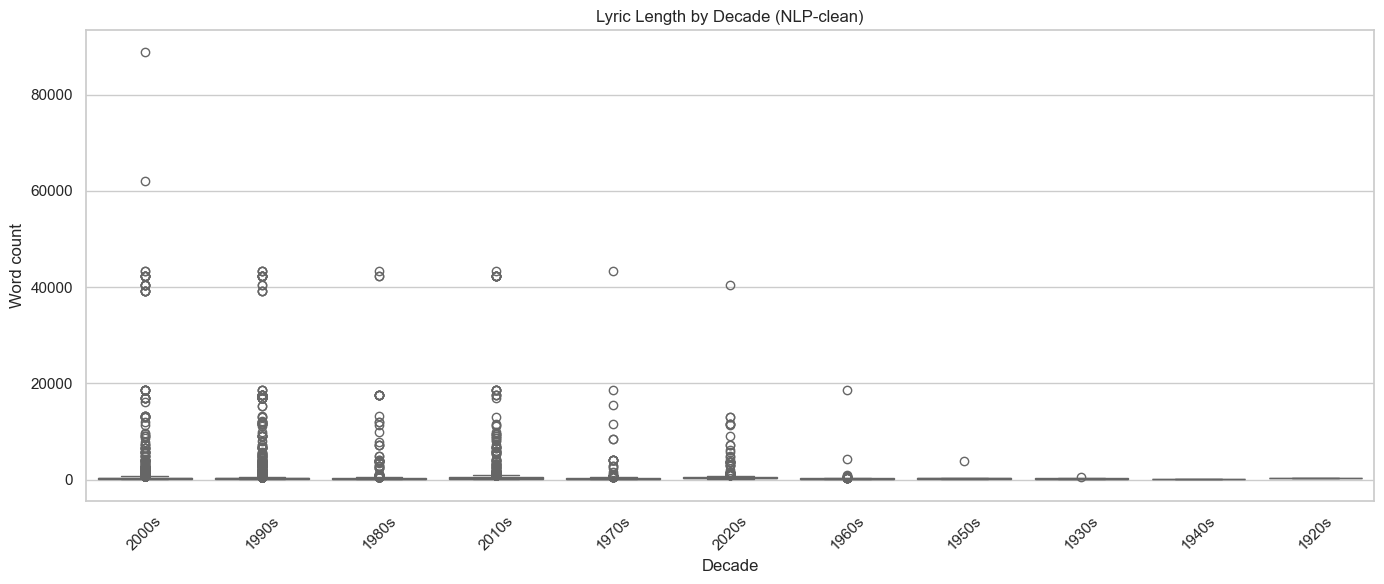

In [34]:
box_df = nlp_df[nlp_df['decade'] != 'Unknown'].copy()

plt.figure(figsize=(14, 6))
sns.boxplot(data=box_df, x='decade', y='lyrics_word_count', color='#e9c46a')
plt.title('Lyric Length by Decade (NLP-clean)')
plt.xlabel('Decade')
plt.ylabel('Word count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / 'box_lyric_length_by_decade.png', dpi=160)
plt.show()

## 9) Vocabulary Exploration
- Most frequent words
- Top words per decade
- TF comparison between decades

Global frequency


In [36]:
FRENCH_STOPWORDS = {
    "je","tu","il","elle","on","nous","vous","ils","elles",
    "me","moi","te","toi","se","soi","lui","leur","leurs","y","en",
    "le","la","les","un","une","des","du","de","d","l","au","aux",
    "mon","ma","mes","ton","ta","tes","son","sa","ses","notre","nos","votre","vos","leur",
    "ce","cet","cette","ces","ça","cela","ca","c",
    "et","ou","où","mais","donc","or","ni","car",
    "que","qui","quoi","dont","quand","comme","si","parce","pour","par","avec","sans","sur","dans","sous","vers","entre","chez",
    "est","etre","être","suis","es","sommes","etes","êtes","sont","ai","as","a","avons","avez","ont",
    "fait","faire","faut","dit","tout","tous","trop","bien","meme","même","rien","jamais","toujours","temps","jour","monde","vie",
    "non","plus","moins","ainsi","aussi","alors","apres","après","avant","pendant","encore",
    "oh","ah","eh","hey","yeah","yeh","huh","wuh","woo","whoa","nan","na","lalala","mmm","hmm", "pas"
}

# Additional explicit non-French/noise tokens found in this corpus
NOISE_OR_NON_FRENCH = {
    "por", "pero", "los", "las", "esta", "está", "siempre", "mierda", "con", "del", "una", "y",
    "uh", "uhh", "ayy", "yo", "ya", "ooh", "aah", "ehh"
}

CLITIC_PREFIXES = {"j","t","m","s","n","l","d","c","qu","jusqu","lorsqu","puisqu"}


def normalize_token(tok: str) -> str:
    tok = tok.lower().replace("’", "'").strip("'")
    if "'" in tok:
        left, right = tok.split("'", 1)
        if left in CLITIC_PREFIXES and right:
            tok = right
    return tok


def extract_clean_tokens(text: str) -> list[str]:
    toks = [normalize_token(t) for t in tokenize(text)]
    out = []
    for t in toks:
        if not t:
            continue
        if t in FRENCH_STOPWORDS or t in NOISE_OR_NON_FRENCH:
            continue
        if len(t) <= 2 or t.isdigit():
            continue
        if not re.search(r"[a-zà-öø-ÿ]", t):
            continue
        if FRENCH_LEXICON is not None and t not in FRENCH_LEXICON:
            continue
        out.append(t)
    return out

all_tokens = []
for txt in nlp_df['lyrics_clean'].astype(str):
    all_tokens.extend(extract_clean_tokens(txt))

word_freq = Counter(all_tokens)
word_freq_df = (
    pd.DataFrame(word_freq.items(), columns=['word', 'count'])
    .sort_values('count', ascending=False)
    .reset_index(drop=True)
)

word_freq_df.head(30)


,word,count
0,amour,37097
1,était,31023
2,veux,28956
3,aime,28890
4,fais,27523
5,sais,27442
6,deux,24078
7,peu,22949
8,peut,21227
9,dis,20766


Top words per decade

In [37]:
top_words_rows = []
word_freq_by_decade = {}

for dec, grp in nlp_df.groupby('decade'):
    dec_tokens = []
    for txt in grp['lyrics_clean'].astype(str):
        dec_tokens.extend(extract_clean_tokens(txt))

    dec_counter = Counter(dec_tokens)
    word_freq_by_decade[dec] = dec_counter

    for w, c in dec_counter.most_common(20):
        top_words_rows.append({'decade': dec, 'word': w, 'count': c})

top_words_per_decade = (
    pd.DataFrame(top_words_rows)
    .sort_values(['decade', 'count'], ascending=[True, False])
    .reset_index(drop=True)
)

top_words_per_decade.head(40)


,decade,word,count
0,1920s,valentine,14
1,1920s,avait,12
2,1920s,petits,10
3,1920s,menton,6
4,1920s,était,5
5,1920s,petons,5
6,1920s,tétons,5
7,1920s,petit,5
8,1920s,pris,3
9,1920s,plu,2


TF frequency comparison between earliest and latest decade

In [38]:
decades_sorted = sorted([d for d in word_freq_by_decade.keys() if d != 'Unknown'])

if len(decades_sorted) >= 2:
    earliest, latest = decades_sorted[0], decades_sorted[-1]
    earliest_counter = word_freq_by_decade[earliest]
    latest_counter = word_freq_by_decade[latest]

    earliest_total = sum(earliest_counter.values())
    latest_total = sum(latest_counter.values())

    all_words_comp = set(earliest_counter) | set(latest_counter)
    tf_compare_df = pd.DataFrame({
        'word': list(all_words_comp),
        'tf_earliest': [earliest_counter[w] / max(earliest_total, 1) for w in all_words_comp],
        'tf_latest': [latest_counter[w] / max(latest_total, 1) for w in all_words_comp],
    })
    tf_compare_df['delta_latest_minus_earliest'] = tf_compare_df['tf_latest'] - tf_compare_df['tf_earliest']
    tf_compare_df = tf_compare_df.sort_values('delta_latest_minus_earliest', ascending=False)
else:
    tf_compare_df = pd.DataFrame(columns=['word', 'tf_earliest', 'tf_latest', 'delta_latest_minus_earliest'])

tf_compare_df.head(30)

,word,tf_earliest,tf_latest,delta_latest_minus_earliest
53421,fais,0.0,0.006592,0.006592
24740,veux,0.0,0.005429,0.005429
30223,ouais,0.0,0.005387,0.005387
36867,sais,0.0,0.005078,0.005078
2205,vais,0.0,0.003021,0.003021
30624,amour,0.0,0.002821,0.002821
39746,tête,0.0,0.002803,0.002803
36340,peu,0.0,0.002726,0.002726
45195,vois,0.0,0.002713,0.002713
28837,mal,0.0,0.002712,0.002712


## 10) Visualizations
Required figures are generated and saved under `masters/figures`.

Barplot songs per decade

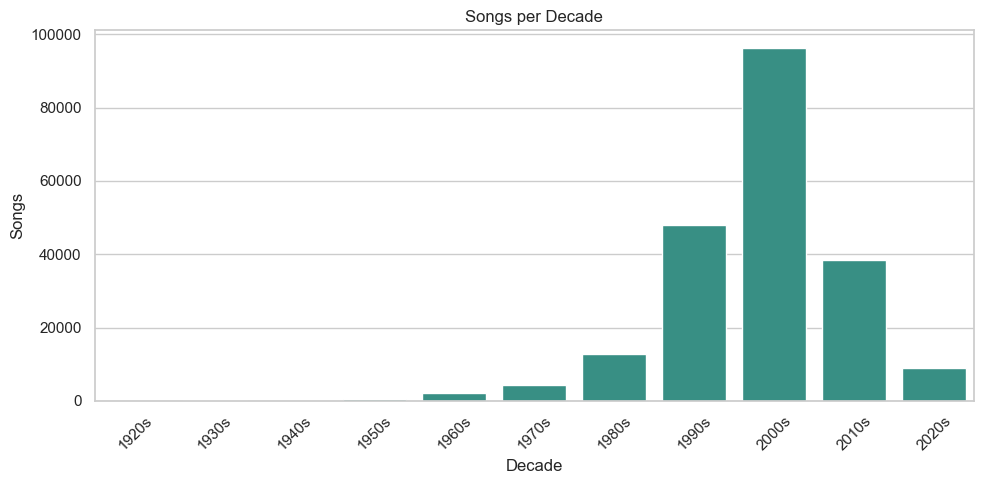

In [39]:
plot_spd = songs_per_decade[songs_per_decade['decade'] != 'Unknown'].sort_values('decade')

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_spd, x='decade', y='songs_count', color='#2a9d8f')
plt.title('Songs per Decade')
plt.xlabel('Decade')
plt.ylabel('Songs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / 'bar_songs_per_decade.png', dpi=160)
plt.show()

Word frequency chart (top 30)

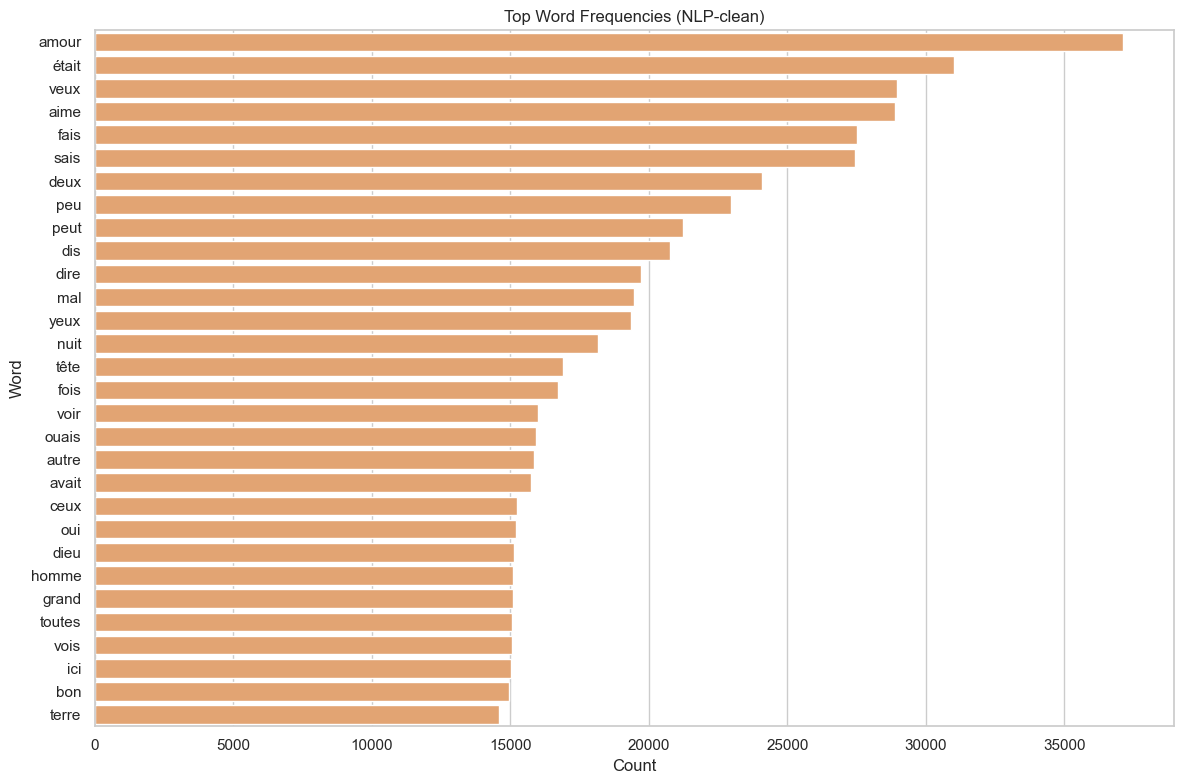

In [40]:
plt.figure(figsize=(12, 8))
sns.barplot(data=word_freq_df.head(30), x='count', y='word', color='#f4a261')
plt.title('Top Word Frequencies (NLP-clean)')
plt.xlabel('Count')
plt.ylabel('Word')
plt.tight_layout()
plt.savefig(FIG_DIR / 'bar_top_words_overall.png', dpi=160)
plt.show()

Vocabulary growth over decades (cumulative unique words)

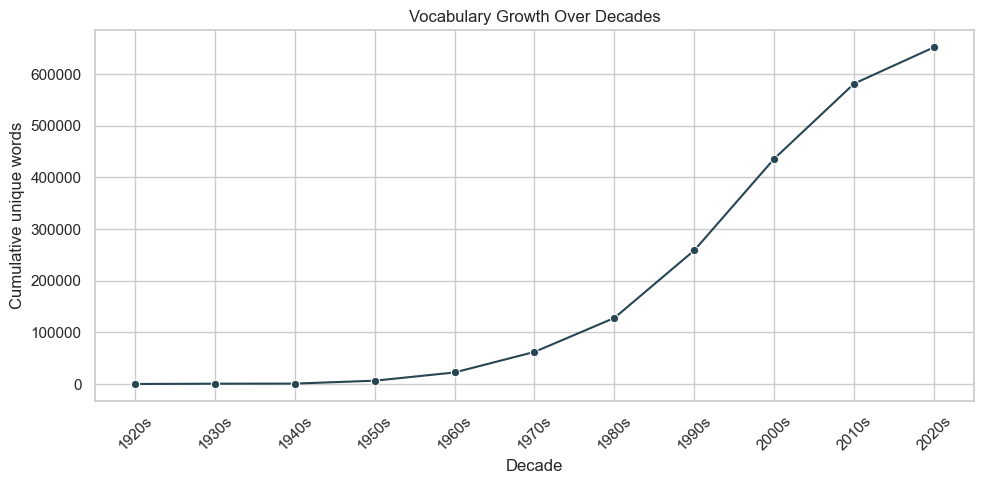

In [41]:
vocab_growth = unique_words_per_decade[unique_words_per_decade['decade'] != 'Unknown'].copy()
vocab_growth = vocab_growth.sort_values('decade')
vocab_growth['cumulative_unique_words'] = vocab_growth['unique_words_count'].cumsum()

plt.figure(figsize=(10, 5))
sns.lineplot(data=vocab_growth, x='decade', y='cumulative_unique_words', marker='o', color='#264653')
plt.title('Vocabulary Growth Over Decades')
plt.xlabel('Decade')
plt.ylabel('Cumulative unique words')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / 'line_vocabulary_growth_over_decades.png', dpi=160)
plt.show()

## 11) Data Sanity Checks
- Impossible years
- Duplicate songs
- Extremely short lyrics

In [42]:
impossible_year_mask = df['year_num'].notna() & ((df['year_num'] < 1850) | (df['year_num'] > 2026))
impossible_year_count = int(impossible_year_mask.sum())

duplicate_mask = overall_df.duplicated(subset=['song_title', 'artist_name', 'year'], keep=False)
duplicate_song_count = int(duplicate_mask.sum())

short_lyrics_count = int((df['has_lyrics'] & (df['lyrics_word_count'] < 20)).sum())

sanity_df = pd.DataFrame([
    {'check': 'impossible_year_count', 'value': impossible_year_count},
    {'check': 'duplicate_song_count_overall', 'value': duplicate_song_count},
    {'check': 'extremely_short_lyrics_count_lt20', 'value': short_lyrics_count},
])

sanity_df

,check,value
0,impossible_year_count,0
1,duplicate_song_count_overall,0
2,extremely_short_lyrics_count_lt20,740


## 12) Save Outputs (CSV + Summary)

In [ ]:
songs_per_decade.to_csv(OUT_DIR / 'eda_songs_per_decade.csv', index=False)
artists_per_decade.to_csv(OUT_DIR / 'eda_artists_per_decade.csv', index=False)
genres_per_decade.to_csv(OUT_DIR / 'eda_genres_per_decade.csv', index=False)
unique_words_per_decade.to_csv(OUT_DIR / 'eda_unique_words_per_decade.csv', index=False)
avg_lyric_len_by_decade.to_csv(OUT_DIR / 'eda_avg_lyric_len_by_decade.csv', index=False)
word_freq_df.to_csv(OUT_DIR / 'eda_word_frequency_overall.csv', index=False)
top_words_per_decade.to_csv(OUT_DIR / 'eda_top_words_per_decade.csv', index=False)
tf_compare_df.to_csv(OUT_DIR / 'eda_tf_compare_earliest_vs_latest_decade.csv', index=False)

overall_export_cols = [
    'year', 'decade', 'song_title', 'artist_credit_name', 'artist_name', 'genre_name',
    'language_name', 'iso_code_3t', 'lyrics_found', 'has_lyrics', 'is_french_verified',
    'lyrics_word_count', 'quality_pass', 'lyrics_clean'
]

nlp_export_cols = [
    'year', 'decade', 'song_title', 'artist_credit_name', 'artist_name', 'genre_name',
    'language_name', 'iso_code_3t', 'lyrics_clean', 'lyrics_word_count',
    'lyrics_source', 'genius_url', 'genius_match_score'
]

overall_export_cols = [c for c in overall_export_cols if c in overall_df.columns]
nlp_export_cols = [c for c in nlp_export_cols if c in nlp_df.columns]

overall_df[overall_export_cols].to_csv(OVERALL_CSV, index=False)
nlp_df[nlp_export_cols].to_csv(NLP_CLEAN_CSV, index=False)

summary = {
    'input_csv': str(INPUT_CSV),
    'dataset_shape': list(df.shape),
    'songs_with_lyrics': int(songs_with_lyrics),
    'songs_without_lyrics': int(songs_without_lyrics),
    'lyrics_availability_pct': float(lyrics_pct),
    'impossible_year_count': impossible_year_count,
    'duplicate_song_count_overall': duplicate_song_count,
    'extremely_short_lyrics_count_lt20': short_lyrics_count,
    'quality_filtered_out_count': int(quality_filtered_out_count),
    'overall_french_music_shape': list(overall_df.shape),
    'nlp_clean_shape': list(nlp_df.shape),
    'output_overall_csv': str(OVERALL_CSV),
    'output_nlp_clean_csv': str(NLP_CLEAN_CSV),
    'figures_dir': str(FIG_DIR),
}

with open(SUMMARY_JSON, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print('Saved summary:', SUMMARY_JSON)
print('Saved overall dataset:', OVERALL_CSV)
print('Saved NLP clean dataset:', NLP_CLEAN_CSV)
print('Figures saved to:', FIG_DIR)

Saved summary: /Users/danvoloshin/Desktop/masters/thesis_french_song_nlp/data/processed/musicbrainz/eda_summary.json
Saved overall dataset: /Users/danvoloshin/Desktop/masters/thesis_french_song_nlp/data/processed/musicbrainz/mb_likely_french_stage2_overall_french_music.csv
Saved NLP clean dataset: /Users/danvoloshin/Desktop/masters/thesis_french_song_nlp/data/processed/musicbrainz/mb_likely_french_stage2_nlp_clean.csv
Figures saved to: /Users/danvoloshin/Desktop/masters/figures


In [45]:
nlp_df.head()

,year,song_title,artist_credit_name,artist_name,language_name,iso_code_3t,release_country_code,artist_country_code,track_id,recording_id,release_id,artist_id,likely_french_score,genre_name,genius_found,genius_song_id,genius_title,genius_artist,genius_url,genius_match_score,lyrics_found,lyrics_text,lyrics_source,lyrics_text.1,year_num,decade,lyrics_raw,has_lyrics,lyrics_clean,lyrics_word_count,quality_pass,is_french_verified
0,2007.0,Rue Lepic,Yves Montand,Yves Montand,French,fra,XE,FR,18502360.0,1939,1593001.0,345.0,5.0,NaN,True,1457202.0,Rue Lepic,Yves Montand,https://genius.com/Yves-montand-rue-lepic-lyrics,1.0,True,1 Contributor\nRue Lepic Lyrics\nRue Lepic\nDa...,genius,NaN,2007.0,2000s,1 Contributor\nRue Lepic Lyrics\nRue Lepic\nDa...,True,Rue Lepic Rue Lepic Dans l'marché qui s'éveill...,176,True,True
1,2004.0,Les Routiers,Yves Montand,Yves Montand,French,fra,FR,FR,24517993.0,1944,2093826.0,345.0,8.0,NaN,True,1608153.0,Les routiers,Yves Montand,https://genius.com/Yves-montand-les-routiers-l...,1.0,True,1 Contributor\nLes routiers Lyrics\nLa route e...,genius,NaN,2004.0,2000s,1 Contributor\nLes routiers Lyrics\nLa route e...,True,Les routiers La route est un long ruban Qui dé...,311,True,True
2,1998.0,Double peine,Zebda,Zebda,French,fra,FR,FR,12514833.0,10822,816938.0,1999.0,7.0,NaN,True,2281345.0,Double peine,Zebda,https://genius.com/Zebda-double-peine-lyrics,1.0,True,3 Contributors\nDouble peine Lyrics\nEn droit ...,genius,NaN,1998.0,1990s,3 Contributors\nDouble peine Lyrics\nEn droit ...,True,"Double peine En droit pénal, on appelle double...",473,True,True
4,1998.0,Je crois que ça va pas être possible,Zebda,Zebda,French,fra,FR,FR,12514832.0,10824,816938.0,1999.0,7.0,NaN,True,945233.0,Je crois que ça va pas être possible,Zebda,https://genius.com/Zebda-je-crois-que-ca-va-pa...,1.0,True,4 Contributors\nJe crois que ça va pas être po...,genius,NaN,1998.0,1990s,4 Contributors\nJe crois que ça va pas être po...,True,Je crois que ça va pas être possible Dans ce m...,764,True,True
5,1998.0,Je suis,Zebda,Zebda,French,fra,FR,FR,12514836.0,10825,816938.0,1999.0,7.0,NaN,True,1134820.0,Je suis,Zebda,https://genius.com/Zebda-je-suis-lyrics,1.0,True,3 Contributors\nJe suis Lyrics\nJe suis le feu...,genius,NaN,1998.0,1990s,3 Contributors\nJe suis Lyrics\nJe suis le feu...,True,Je suis Je suis le feu et l'eau tout à la fois...,394,True,True
